In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [2]:
clean_data = pd.read_parquet("../cleaned_data/clean_yellow_tripdata_2026-01.parquet")

In [3]:
df = clean_data.copy()

In [4]:
df.sample(4)

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,pickup_borough,pickup_zone,pickup_service_type,dropoff_borough,dropoff_zone,dropoff_service_type,fare_type_zone_mismatch,fare_per_distance,non_cc_positive_tip,extra_total_amount
1369252,2,2026-01-23 16:13:24,2026-01-23 16:18:54,3,1.030000,1,False,41,42,1,...,Manhattan,Central Harlem,Boro Zone,Manhattan,Central Harlem North,Boro Zone,None,7.669903,False,2.670288e-07
10851,2,2026-01-01 03:17:58,2026-01-01 03:41:08,1,7.390000,1,False,229,37,1,...,Manhattan,Sutton Place/Turtle Bay North,Yellow Zone,Brooklyn,Bushwick South,Boro Zone,None,4.479026,False,3.051758e-06
906601,1,2026-01-16 05:52:55,2026-01-16 07:13:16,1,22.700001,99,False,19,87,1,...,Queens,Bellerose,Boro Zone,Manhattan,Financial District North,Yellow Zone,None,2.533040,False,9.155273e-07
1250541,2,2026-01-21 20:36:27,2026-01-21 20:47:42,1,2.040000,1,False,141,75,1,...,Manhattan,Lenox Hill West,Yellow Zone,Manhattan,East Harlem South,Boro Zone,None,5.931373,False,-4.577637e-07


# check pickup time < dropoff time

In [5]:
df = df[(df['pickup_datetime'] < df['dropoff_datetime'])]

In [6]:
df.shape

(2577123, 21)

# Check dates, not included in 2026 jan. 2025-12-31 and 2026-02-01 is not midnight trips

In [7]:
print(df[
    (df['pickup_datetime'] >= '2025-12-31') |
    (df['dropoff_datetime'] <= '2026-02-01')
].shape)
df = df[
    (df['pickup_datetime'] >= '2025-12-31') |
    (df['dropoff_datetime'] <= '2026-02-01')
]


(2577123, 21)


# calculate trip duration

In [ ]:
df['trip_duration'] = df['dropoff_datetime'] - df['pickup_datetime']

In [5]:
df['trip_duration'].quantile([0.9995,0.9996,0.9997,0.9998,0.9999,1.0])

0.9995   0 days 02:20:36.430000
0.9996   0 days 02:26:25.720000
0.9997   0 days 02:33:31.057999
0.9998   0 days 02:45:49.487999
0.9999   0 days 03:19:39.033999
1.0000          0 days 07:58:20
Name: trip_duration, dtype: timedelta64[us]

In [6]:
print((df['trip_duration'] > pd.Timedelta(hours=3)).sum())
print((df['trip_duration'] > pd.Timedelta(hours=5)).sum())
print((df['trip_duration'] > pd.Timedelta(hours=5)).sum())
tempdf = df[(df['trip_duration'] > pd.Timedelta(hours=5))]

240
79
79


In [7]:
pd.set_option('display.max_rows', None)
print(tempdf.groupby(['pickup_borough']).size().sort_values(ascending=False))
print(tempdf.groupby(['dropoff_borough']).size().sort_values(ascending=False))

pickup_borough
Manhattan        39
Queens           25
Brooklyn         12
Bronx             1
Staten Island     1
Unknown           1
dtype: int64
dropoff_borough
Brooklyn         24
Queens           23
Manhattan        18
Bronx            11
Staten Island     2
Unknown           1
dtype: int64


<Axes: xlabel='trip_distance', ylabel='trip_duration'>

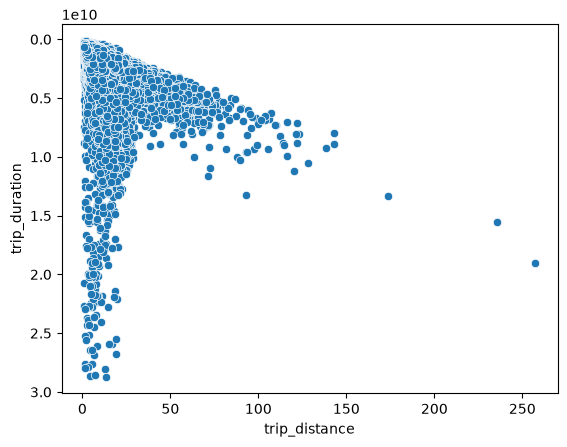

In [8]:
sns.scatterplot(x=df['trip_distance'], y=df['trip_duration'])


In [22]:
(df['trip_duration'] > pd.Timedelta(days=1)).sum()

np.int64(13)

# remove trip_duration > 8 hours

In [23]:
df = df[df['trip_duration'] <= pd.Timedelta(hours=8)]

# remove trips having trip duration less than 2 min

In [9]:
df = df[(df['trip_duration'] >= pd.Timedelta(minutes=2))]

In [10]:
df.shape

(2521956, 22)

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 2521956 entries, 0 to 2622036
Data columns (total 22 columns):
 #   Column                        Dtype          
---  ------                        -----          
 0   vendor_id                     int8           
 1   pickup_datetime               datetime64[us] 
 2   dropoff_datetime              datetime64[us] 
 3   passenger_count               int8           
 4   trip_distance                 float64        
 5   fare_type_id                  float64        
 6   store_and_fwd_flag            str            
 7   pickup_location_id            int32          
 8   dropoff_location_id           int32          
 9   payment_type                  int64          
 10  fare_amount                   float64        
 11  extra_amount                  float64        
 12  mta_tax_amount                float64        
 13  tip_amount                    float64        
 14  tolls_amount                  float64        
 15  improvement_surcharge_amount  f

# save back to the cleaned file 

In [25]:
df.to_parquet('../cleaned_data/clean_yellow_tripdata_2026-01.parquet', index=False)

In [24]:
df.shape

(1773141, 40)

# vendor id 7 is get completely removed - means it has only dirty data

In [14]:
df['vendor_id'].value_counts()

vendor_id
2    1974206
1     547750
Name: count, dtype: int64

# function to clean pickup and dropoff datetime

In [15]:
def clean_pickup_dropoff_datetime(df):

    df = df[(df['pickup_datetime'] < df['dropoff_datetime'])]

    df = df[
        (df['pickup_datetime'] >= '2025-12-31') |
        (df['dropoff_datetime'] <= '2026-02-01')
    ]

    df['trip_duration'] = df['dropoff_datetime'] - df['pickup_datetime']

    df = df[(df['trip_duration'] >= pd.Timedelta(minutes=2))]